In [305]:
#Bibliotecas:
import numpy as np
import pandas as pd
import pywt
import matplotlib.pyplot as plt
from scipy.signal import resample
from scipy.signal import butter, filtfilt
from scipy import signal
from scipy.interpolate import interp1d

In [306]:
# Data extraction: analysis of medio lateral GRF and knee conditions: patellar, femoral and tibial fractures:

# F_ML: medio lateral GRF, left leg:
GRF_F_ML_RAW_left = pd.read_csv(r'GRF_F_ML_RAW_left.csv')

# F_ML: medio lateral GRF, right leg:
GRF_F_ML_RAW_right = pd.read_csv(r'GRF_F_ML_RAW_right.csv')

# Metadata:
metadata = pd.read_csv('GRF_metadata.csv')

# Remove duplicated:
subjects = metadata.drop_duplicates(subset='SUBJECT_ID').copy()

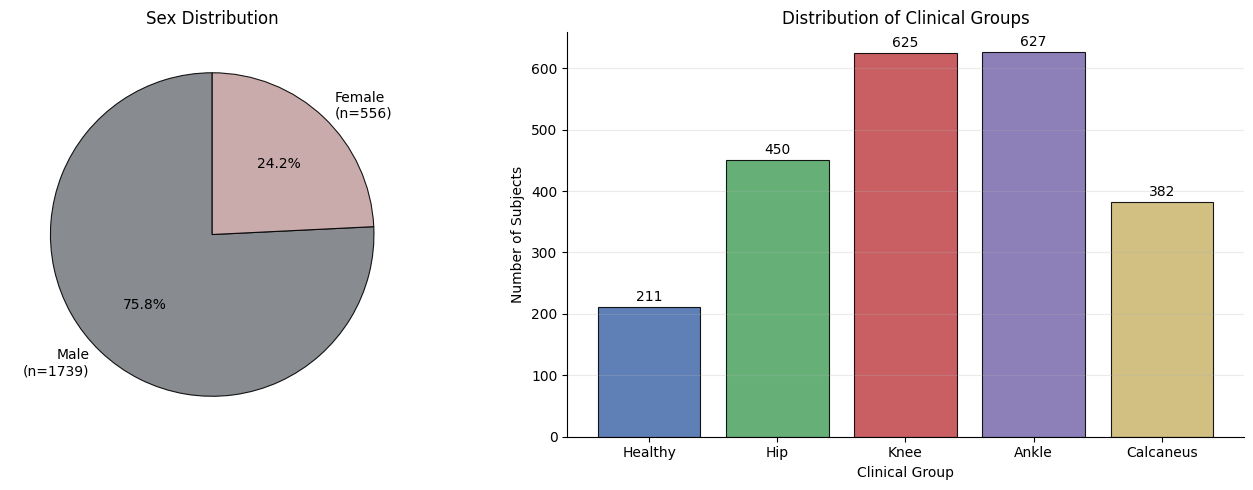

In [307]:
# 1.Data Distribution, sex and problem:
sex_map = {
    1: 'Male',
    0: 'Female'
}

problem_map = {
    'HC': 'Healthy',
    'H': 'Hip',
    'K': 'Knee',
    'A': 'Ankle',
    'C': 'Calcaneus'
}

subjects['SEX_LABEL'] = subjects['SEX'].map(sex_map)
subjects['PROBLEM_LABEL'] = subjects['CLASS_LABEL'].map(problem_map)


# 2.Count sex:
sex_order = ['Male', 'Female']
sex_counts = subjects['SEX_LABEL'].value_counts().reindex(sex_order, fill_value=0)


# 3. Count clinical groups:
problem_order = ['Healthy', 'Hip', 'Knee', 'Ankle', 'Calcaneus']
problem_counts = subjects['PROBLEM_LABEL'].value_counts().reindex(problem_order, fill_value=0)


# Plot:
sex_colors = [
    "#7B7E83",                          # Male
    "#C5A2A3"                           # Female
]

problem_colors = [
    '#4C72B0',                          # Healthy
    '#55A868',                          # Hip
    '#C44E52',                          # Knee
    '#8172B2',                          # Ankle
    '#CCB974'                           # Calcaneus
]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))


# Pie Chart : sex distribution:
wedges, texts, autotexts = axes[0].pie(
    sex_counts.values,
    labels=[
        f'{label}\n(n={value})'
        for label, value in zip(sex_counts.index, sex_counts.values)
    ],
    autopct='%1.1f%%',
    colors=sex_colors,
    startangle=90,
    wedgeprops={
        'edgecolor': 'black',
        'linewidth': 0.8,
        'alpha': 0.9
    }
)

axes[0].set_title('Sex Distribution')


# Bar chart: clinical groups:
bars = axes[1].bar(
    problem_counts.index,
    problem_counts.values,
    color=problem_colors,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

for bar in bars:
    h = bar.get_height()
    axes[1].text(
        bar.get_x() + bar.get_width()/2,
        h + 5,
        f'{int(h)}',
        ha='center',
        va='bottom',
        fontsize=10
    )

axes[1].set_ylabel('Number of Subjects')
axes[1].set_xlabel('Clinical Group')
axes[1].set_title('Distribution of Clinical Groups')

axes[1].grid(axis='y', alpha=0.25)

axes[1].spines['top'].set_visible(False)
axes[1].spines['right'].set_visible(False)


plt.tight_layout()
plt.show()

SEX_LABEL      Male  Female
PROBLEM_LABEL              
Healthy         104     107
Hip             373      77
Knee            425     200
Ankle           498     129
Calcaneus       339      43


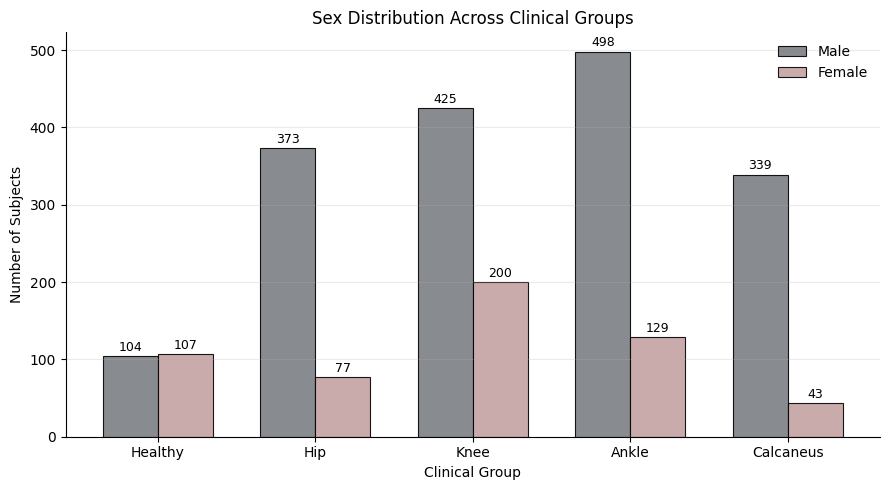

In [308]:
# 5. Define fixed order:

sex_order = ['Male', 'Female']
problem_order = ['Healthy', 'Hip', 'Knee', 'Ankle', 'Calcaneus']

group_counts = pd.crosstab(
    subjects['PROBLEM_LABEL'],
    subjects['SEX_LABEL']
).reindex(index=problem_order, columns=sex_order, fill_value=0)

print(group_counts)


# Plot grouped bar chart:

x = np.arange(len(problem_order))
width = 0.35

plt.figure(figsize=(9,5))

bars_male = plt.bar(
    x - width/2,
    group_counts['Male'],
    width,
    label='Male',
    color=sex_colors[0],
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

bars_female = plt.bar(
    x + width/2,
    group_counts['Female'],
    width,
    label='Female',
    color=sex_colors[1],
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

for bars in [bars_male, bars_female]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 3,
            f'{int(h)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(x, problem_order)
plt.ylabel('Number of Subjects')
plt.xlabel('Clinical Group')
plt.title('Sex Distribution Across Clinical Groups')
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

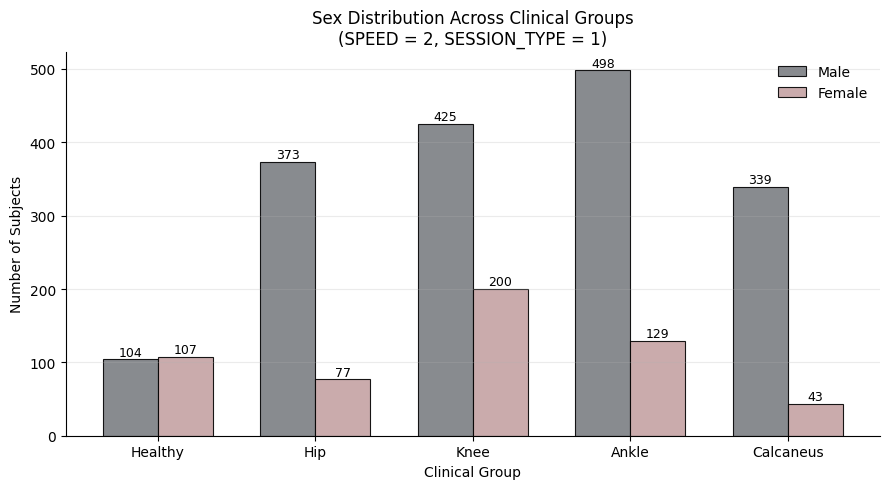

In [309]:
# 6. Filter: SESSION_TYPE = 1, initial measurement and SPEED = 2 fast:

# 6.1 Apply trial level filters:

filtered = metadata[
    (metadata['SPEED'] == 2) &
    (metadata['SESSION_TYPE'] == 1)
].copy()

# Plot grouped bar chart:

x = np.arange(len(problem_order))
width = 0.35

plt.figure(figsize=(9, 5))
bars_male = plt.bar(
    x - width/2,
    group_counts['Male'],
    width,
    label='Male',
    color=sex_colors[0],
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

bars_female = plt.bar(
    x + width/2,
    group_counts['Female'],
    width,
    label='Female',
    color=sex_colors[1],
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

for bars in [bars_male, bars_female]:
    for bar in bars:
        h = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            h + 1,
            f'{int(h)}',
            ha='center',
            va='bottom',
            fontsize=9
        )

plt.xticks(x, problem_order)
plt.ylabel('Number of Subjects')
plt.xlabel('Clinical Group')
plt.title('Sex Distribution Across Clinical Groups\n(SPEED = 2, SESSION_TYPE = 1)')
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

Male
n = 1739
Mean = 87.86
Median = 86.0

Female
n = 556
Mean = 70.36
Median = 67.35


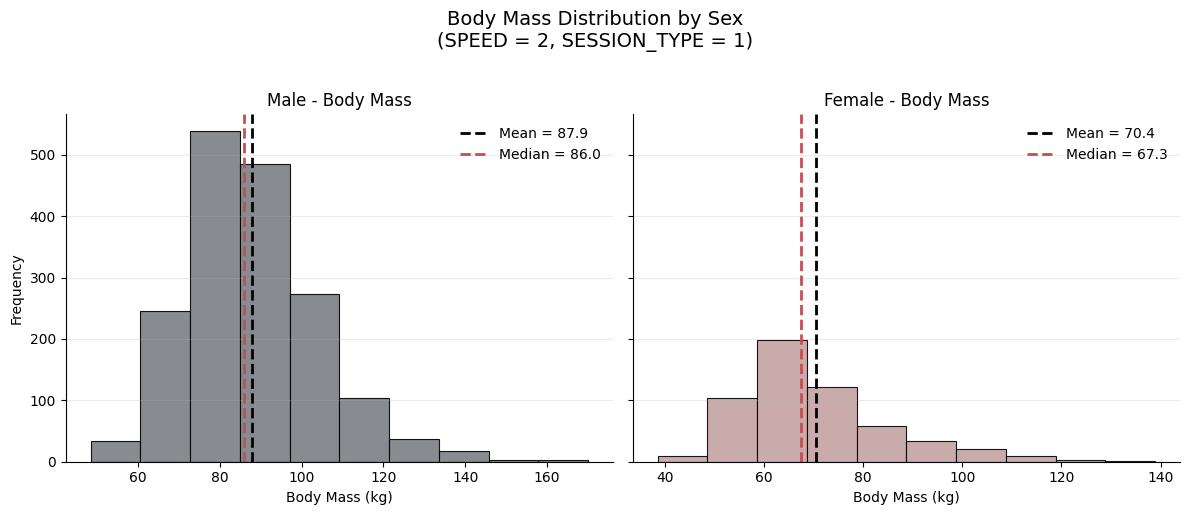

In [310]:
# 7. Extract body mass:

male = subjects[subjects['SEX_LABEL'] == 'Male'].copy()
female = subjects[subjects['SEX_LABEL'] == 'Female'].copy()

male_mass = male['BODY_MASS'].dropna()
female_mass = female['BODY_MASS'].dropna()


# Plot
print('Male')
print('n =', len(male_mass))
print('Mean =', round(male_mass.mean(), 2))
print('Median =', round(male_mass.median(), 2))
print()

print('Female')
print('n =', len(female_mass))
print('Mean =', round(female_mass.mean(), 2))
print('Median =', round(female_mass.median(), 2))

male_color = "#7B7E83"
female_color = "#C5A2A3"
mean_color = "black"
median_color = "#C44E52"

# Histograms
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
axes[0].hist(
    male_mass,
    bins=10,
    color=male_color,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

axes[0].axvline(
    male_mass.mean(),
    color=mean_color,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {male_mass.mean():.1f}'
)

axes[0].axvline(
    male_mass.median(),
    color=median_color,
    linestyle='--',
    linewidth=2,
    label=f'Median = {male_mass.median():.1f}'
)

axes[0].set_title('Male - Body Mass')
axes[0].set_xlabel('Body Mass (kg)')
axes[0].set_ylabel('Frequency')
axes[0].legend(frameon=False)

axes[1].hist(
    female_mass,
    bins=10,
    color=female_color,
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9
)

axes[1].axvline(
    female_mass.mean(),
    color=mean_color,
    linestyle='--',
    linewidth=2,
    label=f'Mean = {female_mass.mean():.1f}'
)

axes[1].axvline(
    female_mass.median(),
    color=median_color,
    linestyle='--',
    linewidth=2,
    label=f'Median = {female_mass.median():.1f}'
)

axes[1].set_title('Female - Body Mass')
axes[1].set_xlabel('Body Mass (kg)')
axes[1].legend(frameon=False)

for ax in axes:
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.grid(axis='y', alpha=0.25)

plt.suptitle('Body Mass Distribution by Sex\n(SPEED = 2, SESSION_TYPE = 1)', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [311]:
# 8.Keep one row per subject:
subjects = filtered.drop_duplicates(subset='SUBJECT_ID').copy()

# 8.1 Map labels:
side_map = {
    0: 'Left',
    1: 'Right',
    2: 'Both'
}

subjects['SEX_LABEL'] = subjects['SEX'].map(sex_map)
subjects['SIDE_LABEL'] = subjects['AFFECTED_SIDE'].map(side_map)

# 8.2 Filter male + knee + weight:
male_knee = subjects[
    (subjects['SEX_LABEL'] == 'Male') &
    (subjects['CLASS_LABEL'] == 'K') &
    (subjects['BODY_MASS'] >= 70) &
    (subjects['BODY_MASS'] <= 90)
].copy()

# 8.3 Separate by side
male_left = male_knee[
    male_knee['SIDE_LABEL'] == 'Left'
]

male_right = male_knee[
    male_knee['SIDE_LABEL'] == 'Right'
]

print('Male knee 70 90 kg:')
print('\nLeft Knee:')
print('Subjects =', len(male_left))
print('IDs =', male_left['SUBJECT_ID'].tolist())
print('\nRight Knee:')
print('Subjects =', len(male_right))
print('IDs =', male_right['SUBJECT_ID'].tolist())

Male knee 70 90 kg:

Left Knee:
Subjects = 96
IDs = [1081, 1091, 1109, 1113, 1126, 1129, 1133, 1134, 1141, 1147, 1150, 1153, 1156, 1162, 1172, 1173, 1179, 1188, 1192, 1199, 1204, 1215, 1218, 1222, 1225, 1229, 1263, 1265, 1269, 1276, 1282, 1284, 1286, 1287, 1291, 1304, 1306, 1321, 1322, 1334, 1344, 1357, 1361, 1362, 1386, 1388, 1389, 1392, 1402, 1404, 1417, 1445, 1450, 1451, 1465, 1474, 1478, 1479, 1486, 1488, 1491, 1504, 1505, 1513, 1515, 1516, 1518, 1533, 1544, 1545, 1550, 1558, 1563, 1568, 1580, 1582, 1588, 1593, 1597, 1605, 1606, 1616, 1618, 1627, 1640, 1651, 1665, 1674, 1680, 1688, 1691, 1692, 1695, 1696, 1698, 1706]

Right Knee:
Subjects = 81
IDs = [1085, 1093, 1118, 1135, 1138, 1145, 1155, 1158, 1161, 1164, 1185, 1187, 1207, 1214, 1226, 1232, 1235, 1236, 1257, 1264, 1273, 1289, 1299, 1307, 1312, 1316, 1318, 1326, 1329, 1343, 1365, 1374, 1379, 1394, 1401, 1415, 1431, 1438, 1459, 1462, 1468, 1480, 1483, 1489, 1509, 1510, 1525, 1532, 1535, 1541, 1546, 1547, 1554, 1560, 1562, 1566, 1

In [312]:
# 9.Balanced dataset:

# 9.1 Separate groups:
healthy = subjects[
    (subjects['SEX_LABEL'] == 'Male') &
    (subjects['CLASS_LABEL'] == 'HC')
].copy()

knee_left = subjects[
    (subjects['SEX_LABEL'] == 'Male') &
    (subjects['CLASS_LABEL'] == 'K') &
    (subjects['SIDE_LABEL'] == 'Left')
].copy()

# 9.2 Count available subjects:
n_healthy = healthy['SUBJECT_ID'].nunique()
n_knee_left = knee_left['SUBJECT_ID'].nunique()

print('Available Healthy Male:', n_healthy)
print('Available Male Knee Left:', n_knee_left)

# 9.3 Robust balanced sampling:
#n = min(n_healthy, n_knee_left, 90)
n = min(n_healthy, n_knee_left)

print('Balanced sample size:', n)
healthy_sample = healthy.sample(
    n=n,
    random_state=42
)

knee_left_sample = knee_left.sample(
    n=n,
    random_state=42
)

print('\nBalanced dataset:')
print('\nHealthy Male:')
print('Total =', len(healthy_sample))
print('IDs =')
print(healthy_sample['SUBJECT_ID'].tolist())
print('\nMale Knee Left:')
print('Total =', len(knee_left_sample))
print('IDs =')
print(knee_left_sample['SUBJECT_ID'].tolist())

Available Healthy Male: 104
Available Male Knee Left: 210
Balanced sample size: 104

Balanced dataset:

Healthy Male:
Total = 104
IDs =
[58, 140, 138, 119, 103, 191, 179, 106, 20, 1, 38, 59, 175, 195, 158, 8, 162, 62, 22, 51, 201, 121, 46, 157, 99, 152, 32, 88, 83, 19, 171, 21, 208, 159, 56, 161, 10, 134, 123, 82, 71, 33, 144, 67, 14, 91, 146, 147, 54, 40, 169, 50, 153, 109, 25, 48, 7, 36, 79, 18, 164, 11, 145, 73, 178, 166, 120, 110, 148, 104, 202, 133, 203, 198, 86, 130, 108, 177, 128, 155, 61, 200, 131, 137, 205, 74, 57, 2, 117, 44, 3, 47, 174, 192, 154, 173, 165, 43, 132, 150, 31, 180, 114, 206]

Male Knee Left:
Total = 104
IDs =
[1173, 1597, 1336, 1695, 1263, 1545, 1210, 1631, 1117, 1688, 1491, 1665, 1723, 1457, 1140, 1295, 1580, 1147, 1588, 1357, 1297, 1230, 1518, 1396, 1395, 1511, 1159, 1455, 1141, 1605, 1677, 1287, 1376, 1284, 1386, 1479, 1627, 1361, 1331, 1561, 1691, 1569, 1533, 1362, 1696, 1286, 1550, 1342, 1373, 1192, 1157, 1640, 1432, 1172, 1148, 1490, 1503, 1282, 1277, 110

In [313]:
healthy_sample['SUBJECT_ID'].nunique()
knee_left_sample['SUBJECT_ID'].nunique()

104

In [314]:
#10. Time Vector Construction:
N = 419                                  # Number of samples collected for left-side F_V_Raw
fs = 250            
# t = np.arange(N)/fs
t = np.linspace(0, 100, N)


#11. Load GRF medio-lateral:
grf = pd.read_csv('GRF_F_ML_RAW_left.csv')

In [315]:
# # # 12.IDs from balanced samples
# saudavel_ids = healthy_sample['SUBJECT_ID'].tolist()
# joelho_ids = knee_left_sample['SUBJECT_ID'].tolist()

# # # 12.1.Filter GRF by selected IDs
# grf_saudavel = grf[grf['SUBJECT_ID'].isin(saudavel_ids)].copy()
# grf_joelho = grf[grf['SUBJECT_ID'].isin(joelho_ids)].copy()

# # # 12.2.Select waveform columns
# signal_cols = [col for col in grf.columns if col.startswith('F_ML_RAW_')]

# # # 12.3.Convert signal columns to numeric
# grf_saudavel[signal_cols] = grf_saudavel[signal_cols].apply(pd.to_numeric, errors='coerce')
# grf_joelho[signal_cols] = grf_joelho[signal_cols].apply(pd.to_numeric, errors='coerce')


# # Verificar a presença de NaNs nas curvas brutas.
# # Caso existam valores ausentes pontuais, o preenchimento é realizado
# # individualmente em cada trial por interpolação linear ao longo do tempo, evitando utilizar médias do grupo e reduzindo distorções na variabilidade intersujeitos.

# # # 12.4.Fill missing values trial by trial

# def fill_nan_trials(df, signal_cols):                                    
#     signals = df[signal_cols].copy()                                     
#     signals = signals.interpolate(axis=1, limit_direction='both')
#     signals = signals.bfill(axis=1).ffill(axis=1)

#     df_filled = df.copy()
#     df_filled[signal_cols] = signals

#     return df_filled

# grf_saudavel = fill_nan_trials(grf_saudavel, signal_cols)
# grf_joelho = fill_nan_trials(grf_joelho, signal_cols)


# # 12.5.Average trials per subject
# grf_saudavel_mean = (
#     grf_saudavel.groupby('SUBJECT_ID')[signal_cols]
#     .mean()
#     .reset_index()
# )

# grf_joelho_mean = (
#     grf_joelho.groupby('SUBJECT_ID')[signal_cols]
#     .mean()
#     .reset_index()
# )

# # 12.6.Convert to arrays
# fx_saudavel = grf_saudavel_mean[signal_cols].to_numpy(dtype=float)
# fx_joelho = grf_joelho_mean[signal_cols].to_numpy(dtype=float)

# # 12.7.Compute group mean and std
# mean_saudavel = np.mean(fx_saudavel, axis=0)
# std_saudavel = np.std(fx_saudavel, axis=0)

# mean_joelho = np.mean(fx_joelho, axis=0)
# std_joelho = np.std(fx_joelho, axis=0)

# # Plot
# plt.figure(figsize=(10, 6))

# plt.plot(t, mean_saudavel, label='Healthy', color='#4C72B0', linewidth=2)
# plt.fill_between(t, mean_saudavel - std_saudavel, mean_saudavel + std_saudavel,
#                  color='#4C72B0', alpha=0.2)

# plt.plot(t, mean_joelho, label='Knee', color='#DD8452', linewidth=2)
# plt.fill_between(t, mean_joelho - std_joelho, mean_joelho + std_joelho,
#                  color='#DD8452', alpha=0.2)

# plt.xlabel('Time (s)')
# plt.ylabel('Fx')
# plt.title('Raw Medio-Lateral GRF\nHealthy vs Knee')
# plt.legend(frameon=False)
# plt.grid(alpha=0.25)
# plt.gca().spines['top'].set_visible(False)
# plt.gca().spines['right'].set_visible(False)
# plt.tight_layout()
# plt.show()


C:\Users\nog_l\AppData\Local\Temp\ipykernel_26588\2801330579.py:48: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()
C:\Users\nog_l\AppData\Local\Temp\ipykernel_26588\2801330579.py:54: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  .reset_index()


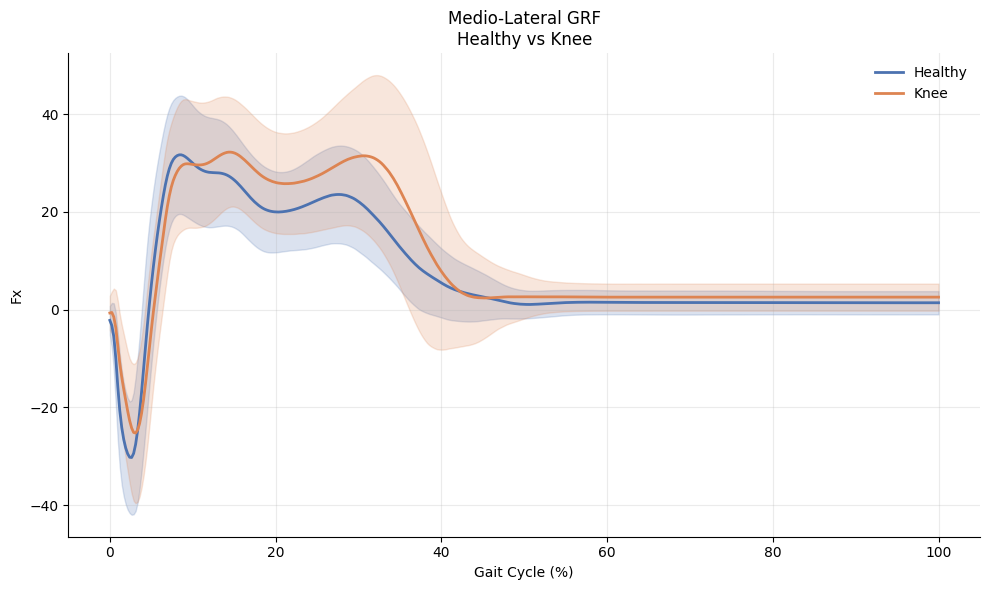

In [324]:
# 12.IDs from balanced samples
saudavel_ids = healthy_sample['SUBJECT_ID'].tolist()
joelho_ids = knee_left_sample['SUBJECT_ID'].tolist()

# 12.1.Filter GRF by selected IDs
grf_saudavel = grf[grf['SUBJECT_ID'].isin(saudavel_ids)].copy()
grf_joelho = grf[grf['SUBJECT_ID'].isin(joelho_ids)].copy()

# 12.2.Select waveform columns
# F_ML_RAW = raw medio-lateral force signal
signal_cols = [col for col in grf.columns if col.startswith('F_ML_RAW_')]

# 12.3.Convert signal columns to numeric
# Non-numeric values are converted to NaN
grf_saudavel[signal_cols] = grf_saudavel[signal_cols].apply(pd.to_numeric, errors='coerce')
grf_joelho[signal_cols] = grf_joelho[signal_cols].apply(pd.to_numeric, errors='coerce')


# 12.4.Fill missing values trial by trial
# Missing values are interpolated individually for each trial along the time axis.
# This avoids using group averages to fill missing data and preserves inter-subject variability.
# Trials are not excluded here because many NaNs may represent the structure of the raw GRF signal,
# such as variable stance duration or regions without valid force-plate contact.
# bfill/ffill are not used to avoid creating artificial plateaus at the beginning or end of the signal.

def fill_nan_trials(df, signal_cols):
    signals = df[signal_cols].copy()

    # Interpolate missing values along each waveform/trial
    signals = signals.interpolate(axis=1, limit_direction='both')

    df_filled = df.copy()
    df_filled[signal_cols] = signals

    return df_filled

grf_saudavel = fill_nan_trials(grf_saudavel, signal_cols)
grf_joelho = fill_nan_trials(grf_joelho, signal_cols)


# 12.5.Average trials per subject
# Each subject may have more than one trial.
# First, trials are averaged within each subject to avoid giving more weight
# to subjects with more trials.
grf_saudavel_mean = (
    grf_saudavel.groupby('SUBJECT_ID')[signal_cols]
    .mean()
    .reset_index()
)

grf_joelho_mean = (
    grf_joelho.groupby('SUBJECT_ID')[signal_cols]
    .mean()
    .reset_index()
)


# 12.6.Convert subject-level curves to arrays
fx_saudavel = grf_saudavel_mean[signal_cols].to_numpy(dtype=float)
fx_joelho = grf_joelho_mean[signal_cols].to_numpy(dtype=float)


# 12.7.Compute group mean and standard deviation
mean_saudavel = np.mean(fx_saudavel, axis=0)
std_saudavel = np.std(fx_saudavel, axis=0)

mean_joelho = np.mean(fx_joelho, axis=0)
std_joelho = np.std(fx_joelho, axis=0)


# 12.8.Plot raw medio-lateral GRF
plt.figure(figsize=(10, 6))

plt.plot(
    t,
    mean_saudavel,
    label='Healthy',
    color='#4C72B0',
    linewidth=2
)

plt.fill_between(
    t,
    mean_saudavel - std_saudavel,
    mean_saudavel + std_saudavel,
    color='#4C72B0',
    alpha=0.2
)

plt.plot(
    t,
    mean_joelho,
    label='Knee',
    color='#DD8452',
    linewidth=2
)

plt.fill_between(
    t,
    mean_joelho - std_joelho,
    mean_joelho + std_joelho,
    color='#DD8452',
    alpha=0.2
)

plt.xlabel('Gait Cycle (%)')
plt.ylabel('Fx')
plt.title('Medio-Lateral GRF\nHealthy vs Knee')
plt.legend(frameon=False)
plt.grid(alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

In [317]:
print('Healthy trials:', len(grf_saudavel))
print('Knee trials:', len(grf_joelho))

print('Healthy subjects:', grf_saudavel['SUBJECT_ID'].nunique())
print('Knee subjects:', grf_joelho['SUBJECT_ID'].nunique())

Healthy trials: 3724
Knee trials: 3276
Healthy subjects: 104
Knee subjects: 104


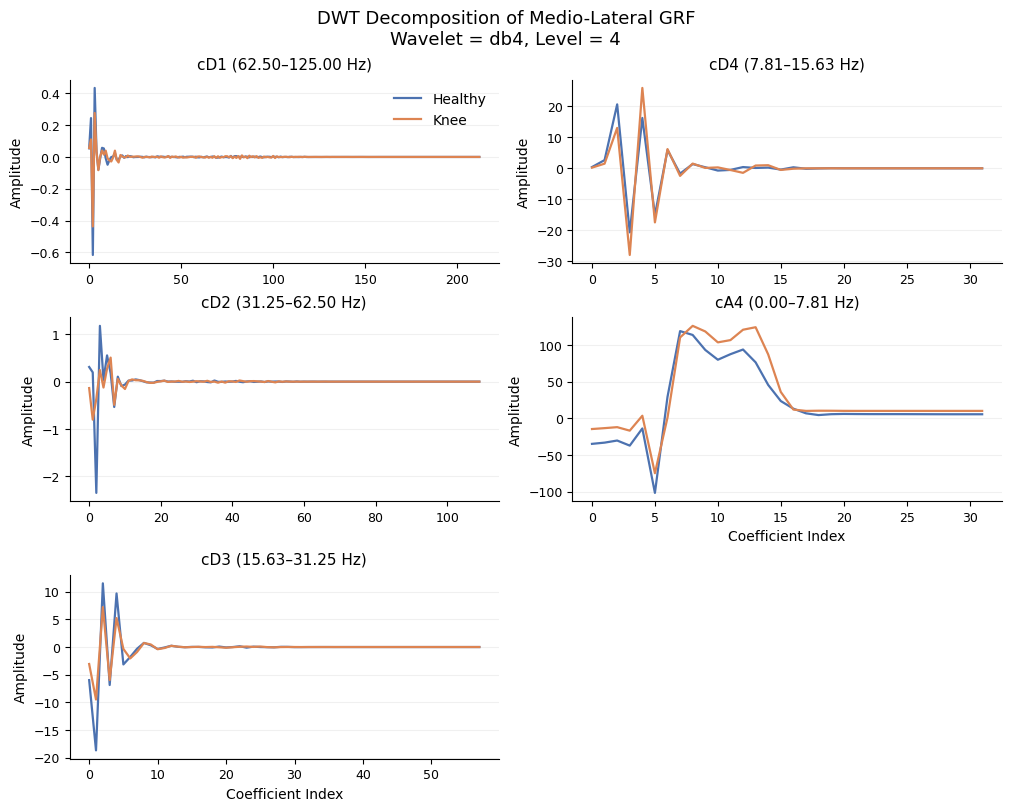

In [319]:
# 13. Discrete Wavelet Transform (DWT) with 4 levels
# The input signals are subject-level medio-lateral GRF curves.

# Parameters
fs = 250
wavelet_nome = 'db4'
nivel = 4


# 13.1 Function to compute mean DWT coefficients across subjects
def mean_dwt_coeffs(signals, wavelet_nome='db4', nivel=4):
    coeffs_all = []

    for signal in signals:
        signal = np.asarray(signal, dtype=np.float64).flatten()

        coeffs = pywt.wavedec(
            signal,
            wavelet=wavelet_nome,
            level=nivel
        )

        coeffs_all.append(coeffs)

    mean_coeffs = []

    # coeffs order from pywt.wavedec:
    # [cA4, cD4, cD3, cD2, cD1]
    for i in range(len(coeffs_all[0])):
        stacked = np.vstack([c[i] for c in coeffs_all])
        mean_coeffs.append(np.mean(stacked, axis=0))

    return mean_coeffs


# 13.2 Compute mean DWT coefficients from medio-lateral GRF signals
mean_saudavel_coeffs = mean_dwt_coeffs(
    fx_saudavel,
    wavelet_nome=wavelet_nome,
    nivel=nivel
)

mean_joelho_coeffs = mean_dwt_coeffs(
    fx_joelho,
    wavelet_nome=wavelet_nome,
    nivel=nivel
)


# 13.3 Reorder coefficients from high to low frequency
# Original pywt order: [cA4, cD4, cD3, cD2, cD1]
# Desired order:       [cD1, cD2, cD3, cD4, cA4]

ordem_saudavel = [
    mean_saudavel_coeffs[4],  # cD1
    mean_saudavel_coeffs[3],  # cD2
    mean_saudavel_coeffs[2],  # cD3
    mean_saudavel_coeffs[1],  # cD4
    mean_saudavel_coeffs[0],  # cA4
]

ordem_joelho = [
    mean_joelho_coeffs[4],    # cD1
    mean_joelho_coeffs[3],    # cD2
    mean_joelho_coeffs[2],    # cD3
    mean_joelho_coeffs[1],    # cD4
    mean_joelho_coeffs[0],    # cA4
]


# 13.4 Frequency bands for fs = 250 Hz and level = 4
labels = [
    'cD1 (62.50–125.00 Hz)',
    'cD2 (31.25–62.50 Hz)',
    'cD3 (15.63–31.25 Hz)',
    'cD4 (7.81–15.63 Hz)',
    'cA4 (0.00–7.81 Hz)'
]

healthy_color = '#4C72B0'
knee_color = '#DD8452'


# 13.5 Plot DWT coefficients
fig, axes = plt.subplots(
    3, 2,
    figsize=(10, 8),
    constrained_layout=True
)

axes = axes.flatten()

# Plot layout positions:
# left column:  cD1, cD2, cD3
# right column: cD4, cA4
posicoes = [0, 2, 4, 1, 3]

for i in range(5):
    ax = axes[posicoes[i]]
    x = np.arange(len(ordem_saudavel[i]))

    ax.plot(
        x,
        ordem_saudavel[i],
        color=healthy_color,
        linewidth=1.6,
        label='Healthy' if i == 0 else None
    )

    ax.plot(
        x,
        ordem_joelho[i],
        color=knee_color,
        linewidth=1.6,
        label='Knee' if i == 0 else None
    )

    ax.set_title(labels[i], fontsize=11, pad=8)
    ax.set_ylabel('Amplitude')
    ax.grid(axis='y', alpha=0.18)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.tick_params(axis='both', labelsize=9)

axes[4].set_xlabel('Coefficient Index')   # cD3
axes[3].set_xlabel('Coefficient Index')   # cA4
axes[0].legend(frameon=False, loc='upper right')
axes[5].axis('off')

fig.suptitle(
    'DWT Decomposition of Medio-Lateral GRF\nWavelet = db4, Level = 4',
    fontsize=13
)

plt.show()

Healthy energy shape: (104, 5)
Knee energy shape: (104, 5)

Mean energy - Healthy
cA4    106781.375598
cD4      2714.001941
cD3      1113.195981
cD2        69.458091
cD1         3.539412
dtype: float64

Mean energy - Knee
cA4    151476.714597
cD4      3411.847638
cD3       622.280197
cD2        53.082904
cD1         2.033423
dtype: float64


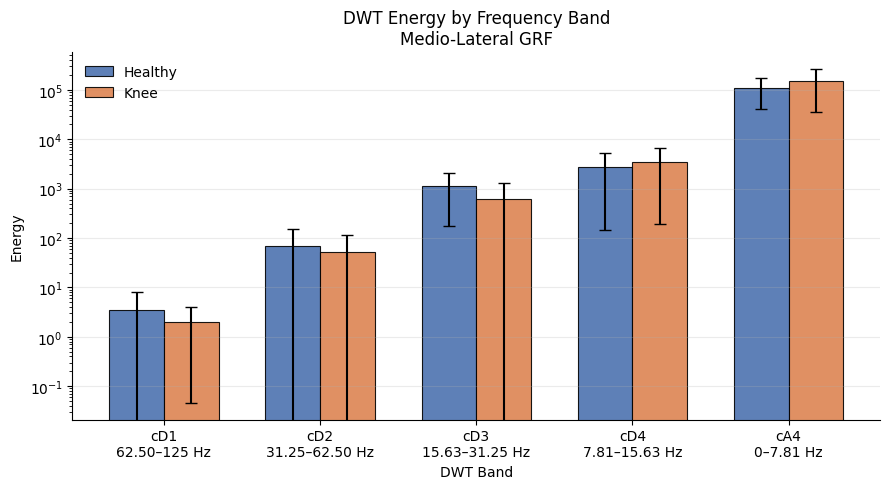

In [322]:
# 14. Compute DWT energy per frequency band
# Energy is calculated for each subject-level medio-lateral GRF curve.

def dwt_energy_per_signal(signals, wavelet_nome='db4', nivel=4):
    energies = []

    for signal in signals:
        signal = np.asarray(signal, dtype=np.float64).flatten()

        coeffs = pywt.wavedec(
            signal,
            wavelet=wavelet_nome,
            level=nivel
        )

        # pywt.wavedec output order:
        # [cA4, cD4, cD3, cD2, cD1]
        energy = [np.sum(c**2) for c in coeffs]
        energies.append(energy)

    return np.array(energies)


# 14.1 Compute energies
energy_saudavel = dwt_energy_per_signal(
    fx_saudavel,
    wavelet_nome=wavelet_nome,
    nivel=nivel
)

energy_joelho = dwt_energy_per_signal(
    fx_joelho,
    wavelet_nome=wavelet_nome,
    nivel=nivel
)


# 14.2 Build DataFrames for inspection
energy_cols = ['cA4', 'cD4', 'cD3', 'cD2', 'cD1']

df_energy_saudavel = pd.DataFrame(energy_saudavel, columns=energy_cols)
df_energy_joelho = pd.DataFrame(energy_joelho, columns=energy_cols)

print('Healthy energy shape:', df_energy_saudavel.shape)
print('Knee energy shape:', df_energy_joelho.shape)

print('\nMean energy - Healthy')
print(df_energy_saudavel.mean())

print('\nMean energy - Knee')
print(df_energy_joelho.mean())


# 14.3 Reorder from high to low frequency
ordem_cols = ['cD1', 'cD2', 'cD3', 'cD4', 'cA4']

mean_energy_saudavel = df_energy_saudavel[ordem_cols].mean()
std_energy_saudavel = df_energy_saudavel[ordem_cols].std()

mean_energy_joelho = df_energy_joelho[ordem_cols].mean()
std_energy_joelho = df_energy_joelho[ordem_cols].std()


# 14.4 Labels for fs = 250 Hz and DWT level = 4
labels = [
    'cD1\n62.50–125 Hz',
    'cD2\n31.25–62.50 Hz',
    'cD3\n15.63–31.25 Hz',
    'cD4\n7.81–15.63 Hz',
    'cA4\n0–7.81 Hz'
]


# 14.5 Plot DWT energy by frequency band
x = np.arange(len(labels))
width = 0.35

plt.figure(figsize=(9, 5))

plt.bar(
    x - width/2,
    mean_energy_saudavel,
    width,
    yerr=std_energy_saudavel,
    label='Healthy',
    color='#4C72B0',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9,
    capsize=4
)

plt.bar(
    x + width/2,
    mean_energy_joelho,
    width,
    yerr=std_energy_joelho,
    label='Knee',
    color='#DD8452',
    edgecolor='black',
    linewidth=0.8,
    alpha=0.9,
    capsize=4
)

plt.xticks(x, labels)
plt.ylabel('Energy')
plt.xlabel('DWT Band')
plt.yscale('log')
plt.title('DWT Energy by Frequency Band\nMedio-Lateral GRF')
plt.legend(frameon=False)
plt.grid(axis='y', alpha=0.25)
plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()